# From a photograph to a posed MHR body

The whole pipeline, in the order it runs:

1. **Training pairs** — solve an MHR pose from ASPset's 3D keypoints, move it into the frame of
   the camera that filmed it, and cut the person out of the picture.
2. **Train** a network to read that pose back out of the crop alone.
3. **Infer** on a person the network has never seen, and look at the result.

The real work lives in four plain Python files next to this notebook, and in `../mhr_posing/`.
This notebook runs them in order and shows what comes out, so every cell here is short.

## 0. Setup

In [1]:
%matplotlib inline

import pathlib
import sys
import time
import warnings

import matplotlib.pyplot as plt
import numpy as np
import torch

warnings.filterwarnings("ignore")
plt.rcParams.update({"figure.dpi": 120, "font.size": 8})

HERE = pathlib.Path.cwd()
if HERE.name != "mhr_pose":
    HERE = HERE / "mhr_pose"
ROOT = HERE.parent
sys.path[:0] = [str(ROOT), str(ROOT / "mhr_posing"), str(HERE)]

import analytic_ik as ik          # the solver: 3D keypoints -> an MHR pose
import mhr_scene as scene         # putting a solved body in front of a camera
import model as net               # the network, and the crop <-> camera sums
import predict as P               # turning an answer back into MHR parameters
import train as T                 # the six marks and the training pieces
from mhr_kit.model import faces
from mhr_kit.render import render

DATA = HERE / "data"
rig = ik.Rig()
constants = net.rig_constants(rig)
triangles = faces(rig.model)

print(f"{len(rig.parameter_names)} MHR parameters, of which the network predicts "
      f"{len(net.ARTICULATION)} joint angles + a heading + a position")

204 MHR parameters, of which the network predicts 31 joint angles + a heading + a position


## 1. The training pairs

`make_dataset.py` does the work. It takes about five minutes, so this skips it if it has
already run.

The one step that is easy to get wrong and silent when it is: ASPset's world origin is the
**left** camera, so a clip filmed by the mid or right camera is described from a camera that
did not take the picture. Two thirds of the clips here are mid or right.

In [2]:
if (DATA / "labels.npz").exists():
    print("already built - delete mhr_pose/data to rebuild")
else:
    import make_dataset
    make_dataset.main()

labels = dict(np.load(DATA / "labels.npz", allow_pickle=False))
people, counts = np.unique(labels["subject"], return_counts=True)
views, view_counts = np.unique(labels["view"], return_counts=True)

print(f"{len(labels['name'])} crops")
print("  people:", dict(zip(people, counts)))
print("  camera:", dict(zip(views, view_counts)))

already built - delete mhr_pose/data to rebuild
2764 crops
  people: {np.str_('1e28'): np.int64(1438), np.str_('8a59'): np.int64(1326)}
  camera: {np.str_('left'): np.int64(884), np.str_('mid'): np.int64(931), np.str_('right'): np.int64(949)}


### Are the answers right?

Before training anything, draw the answers themselves: render each solved body through the
camera that took its picture. If the placement maths is wrong, the body lands somewhere other
than on the person and it is obvious here rather than fifty epochs later.

In [3]:
%matplotlib inline

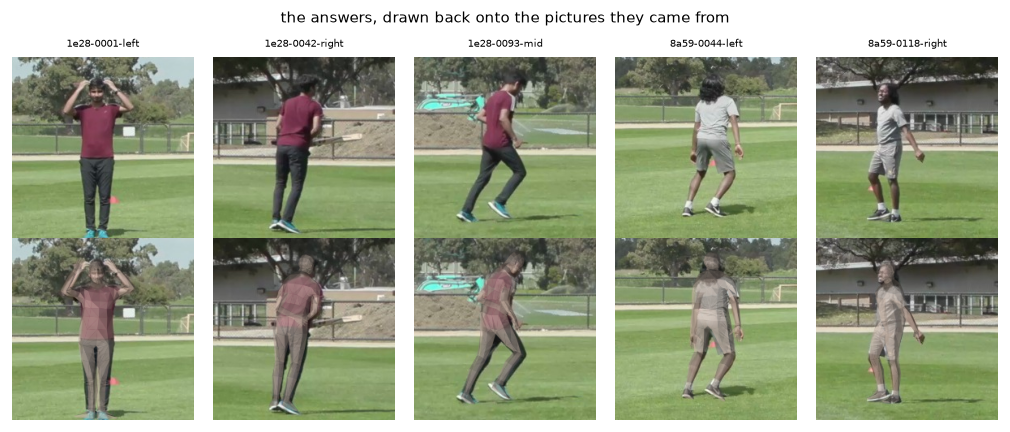

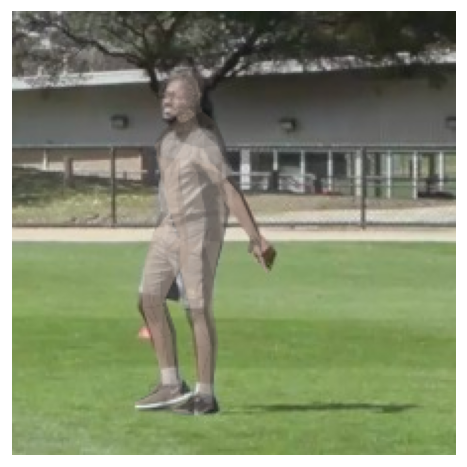

In [4]:
def overlay(index, pose, alpha=0.6):
    """An MHR pose drawn over the crop it belongs to."""
    image, where = P.read_example(labels, index)
    photograph = (image[0].permute(1, 2, 0).numpy() * 255).astype(np.uint8)
    mesh = ik.mesh_from_pose(rig, pose)
    return photograph, render(mesh, triangles, P.crop_camera(where), background=photograph, alpha=alpha)


examples = np.linspace(0, len(labels["name"]) - 1, 5).astype(int)
figure, panels = plt.subplots(2, len(examples), figsize=(1.7 * len(examples), 3.6))
for column, index in enumerate(examples):
    photograph, drawn = overlay(index, labels["pose"][index])
    panels[0, column].imshow(photograph)
    panels[1, column].imshow(drawn)
    panels[0, column].set_title(str(labels["clip"][index]), fontsize=6)
    for row in (0, 1):
        panels[row, column].axis("off")
panels[0, 0].set_ylabel("photograph")
figure.suptitle("the answers, drawn back onto the pictures they came from", fontsize=9)
figure.tight_layout()

plt.figure()
plt.imshow(drawn)
plt.axis("off")
plt.show()

## 2. The network

DINOv2 looks at the crop; fifteen questions - one per joint group, one about the camera - each
read what they need out of it.

Before training, work out **the bar**: how well you would do by ignoring the picture entirely
and always answering with the average pose. Any score worse than this means nothing has been
learned from the picture at all.

In [5]:
HELD_OUT = "1e28"        # one whole person kept back; the only honest split with two people
BATCH_SIZE = 8

labels, training_crops, held_out_crops = T.load_data(HELD_OUT, BATCH_SIZE)

training on 1326 crops, validating on 1438 crops of person 1e28


## 3. Training

Only the head is trained - the backbone is frozen, so its 22 million weights never move and
no gradient is kept for it. On the CPU a batch of 24 takes about two seconds, so an epoch here is roughly three minutes.
This runs a few epochs so the notebook finishes in reasonable time; the saved network in
`data/network.pt` came from a longer run of `train.py`, which is the same loop.

Not on an Apple graphics card: MHR's forward pass is a TorchScript program that only runs on
the CPU, and with the gradient crossing between devices the second step never finishes.

In [ ]:
from tqdm.auto import tqdm

EPOCHS = 25
DEVICE = torch.device("mps")

constants["spread"] = torch.tensor(labels["std"][:len(net.ARTICULATION)], dtype=torch.float32)
base_pose = torch.tensor(labels["base_pose"], dtype=torch.float32)[None]
low = torch.tensor(labels["low"], dtype=torch.float32)
high = torch.tensor(labels["high"], dtype=torch.float32)

network = net.PoseNet(torch.tensor(labels["mean"], dtype=torch.float32),
                      torch.tensor(labels["std"], dtype=torch.float32))
network.to(DEVICE)

# Only the head is trained. The backbone is frozen inside model.PoseNet, so asking
# for the parameters that still want a gradient gives exactly the head.
learning = [parameter for parameter in network.parameters() if parameter.requires_grad]
optimiser = torch.optim.AdamW(learning, lr=3e-4, weight_decay=0.01)
print(f"training {sum(p.numel() for p in learning)/1e6:.2f}M weights; the backbone's "
      f"{sum(p.numel() for p in network.backbone.parameters())/1e6:.1f}M are frozen")

history, best = [], float("inf")
for epoch in range(1, EPOCHS + 1):
    network.train()
    started = time.time()
    for batch in tqdm(training_crops, desc=f"epoch {epoch} [train]", leave=False):
        marks = T.score(T.predict(network, batch, DEVICE), batch,
                        constants, base_pose, rig.model, low, high)
        loss = sum(T.WEIGHTS[name] * mark for name, mark in marks.items())
        optimiser.zero_grad()
        loss.backward()
        torch.nn.utils.clip_grad_norm_(network.parameters(), 1.0)
        optimiser.step()

    network.eval()
    totals = {}
    with torch.no_grad():
        for batch in tqdm(held_out_crops, desc=f"epoch {epoch} [eval]", leave=False):
            for name, value in T.report(T.predict(network, batch, DEVICE), batch,
                                        constants, base_pose, rig.model).items():
                totals[name] = totals.get(name, 0.0) + float(value)
    scored = {name: value / len(held_out_crops) for name, value in totals.items()}
    history.append(scored)
    print(f"epoch {epoch}  " + "  ".join(f"{n} {v:.2f}" for n, v in scored.items())
          + f"   [{time.time() - started:.0f}s]")

    if scored["pose error (cm)"] < best:
        best = scored["pose error (cm)"]
        torch.save({"network": network.state_dict(), "mean": labels["mean"],
                    "std": labels["std"], "base_pose": labels["base_pose"], "epoch": epoch},
                   DATA / "network-from-notebook.pt")

## 4. Inference

A few epochs will not beat the longer run, so this loads the saved network by default.
Point `CHECKPOINT` at `network-from-notebook.pt` to use the one just trained instead.

In [6]:
CHECKPOINT = DATA / "network-from-notebook.pt"

saved = torch.load(CHECKPOINT, map_location="cpu", weights_only=False)
trained = net.PoseNet(torch.tensor(saved["mean"], dtype=torch.float32),
                      torch.tensor(saved["std"], dtype=torch.float32))
trained.load_state_dict(saved["network"])
trained.eval()
saved_base = torch.tensor(saved["base_pose"], dtype=torch.float32)[None]
print(f"{CHECKPOINT.name}, saved at epoch {saved['epoch']}")


def read_pose(index):
    """One crop in, an MHR pose and the joints it puts in space out."""
    image, where = P.read_example(labels, index)
    with torch.no_grad():
        rotation, articulation, camera = trained(image, where["box"], where["focal"], where["centre"])
        position = net.translation_from_camera(camera, where["box"], where["focal"], where["centre"])
        joints = net.place_body(
            net.body_in_own_frame(rig.model, saved_base, constants["indices"], articulation,
                                  constants["root"], constants["keypoints"]),
            rotation, position)
    pose = P.to_mhr_parameters(rig, saved_base[0].numpy(), articulation[0].numpy(),
                               rotation[0].numpy(), position[0].numpy())
    return image, pose, joints[0].numpy(), where

network-from-notebook.pt, saved at epoch 19


### The prediction beside the truth

Both bodies are drawn through the same camera, so anything you see is the network and not the
projection. One frame is taken from the middle of each of six held-out clips.

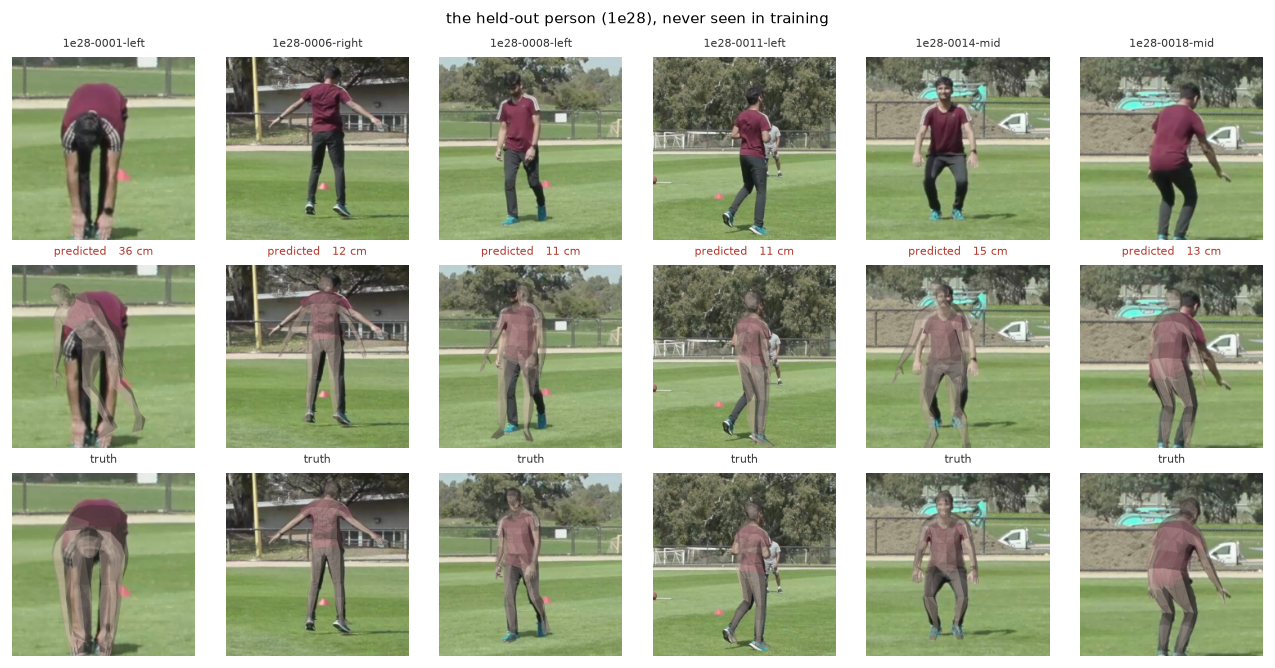

In [9]:
held = np.flatnonzero(labels["subject"] == HELD_OUT)
clips = labels["clip"][held]
chosen = [held[np.flatnonzero(clips == clip)[np.count_nonzero(clips == clip) // 2]]
          for clip in list(dict.fromkeys(clips))[:6]]

figure, panels = plt.subplots(3, len(chosen), figsize=(1.8 * len(chosen), 5.6))
for column, index in enumerate(chosen):
    image, pose, joints, _ = read_pose(index)
    truth = labels["joints_3d"][index]
    error = np.linalg.norm((joints - joints[0]) - (truth - truth[0]), axis=1).mean()

    photograph, predicted = overlay(index, pose)
    _, actual = overlay(index, labels["pose"][index])

    for row, (picture, title) in enumerate([(photograph, str(labels["clip"][index])),
                                            (predicted, f"predicted   {error:.0f} cm"),
                                            (actual, "truth")]):
        panels[row, column].imshow(picture)
        panels[row, column].axis("off")
        panels[row, column].set_title(title, fontsize=6.5,
                                      color="#b03a2e" if row == 1 else "#333333")
figure.suptitle(f"the held-out person ({HELD_OUT}), never seen in training", fontsize=9)
figure.tight_layout()
plt.show()

### The same body in a 3D scene, at the distance and heading it was seen from

In [11]:
import plotly.io as pio
pio.renderers.default = "notebook"

the parameter vector agrees with the network to 0.000031 cm
where it puts the person: 25.2 m, facing the camera (+22°)
where they really were:   18.1 m, back to the camera (+168°)
   l_elbow_bend     -0.184 rad
   r_elbow_bend     -0.169 rad
   l_knee_bend      +0.880 rad
   r_knee_bend      +0.825 rad


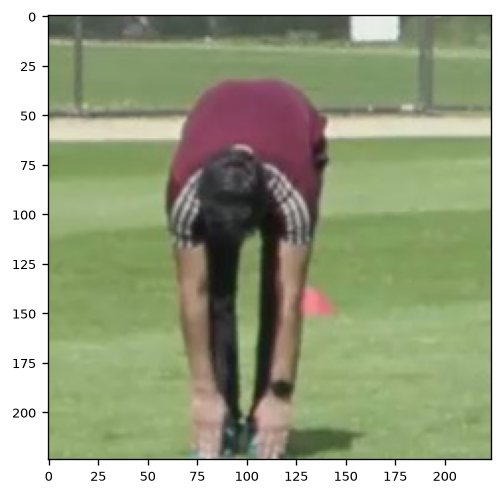

In [12]:
index = int(chosen[0])
image, pose, joints, where = read_pose(index)

rebuilt = rig.forward_kinematics(pose)[0][constants["keypoints"].numpy()]
print(f"the parameter vector agrees with the network to {np.abs(rebuilt - joints).max():.6f} cm")
print(f"where it puts the person: {scene.describe(rig, pose)}")
print(f"where they really were:   {scene.describe(rig, labels['pose'][index])}")

for name, value in list(zip(net.ARTICULATION, pose[constants["indices"].numpy()]))[-4:]:
    print(f"   {name:16s} {value:+.3f} rad")
    
image, pose, joints, where = read_pose(index)

figure = scene.scene_figure([ik.mesh_from_pose(rig, pose)], triangles,
                            names=["what the network read"],
                            title=scene.describe(rig, pose), rig=rig, poses=[pose])
figure.show()

plt.imshow(image[0].permute(1, 2, 0).numpy())

## How to read any of these numbers

| | pose error |
|---|---|
| guessing the average pose | 29.8 cm - anything worse has learned nothing from the picture |
| this pipeline, 13 epochs | 14.7 cm |
| perfect answers, one fixed body build | 2.05 cm - the ceiling |

And the honest framing: 1 326 training crops of **one person** is not a training set. These
numbers show the pipeline works end to end. They do not show the network is good, and with
this data they cannot. `README.md` lists what to do about that, in order.